In [1]:
import pandas as pd

df = pd.read_csv("spectra_441.csv")


spectra_df = df.pivot_table(
    index=["h2", "p"],
    columns="wavelength",
    values="abs"
)

spectra_df = spectra_df.sort_index(axis=1)

print("Số phổ:", spectra_df.shape[0])
print("Số điểm mỗi phổ:", spectra_df.shape[1])


Số phổ: 441
Số điểm mỗi phổ: 1001


In [2]:

wavelengths = spectra_df.columns.values.astype(float)

mask_in  = (wavelengths >= 4000) & (wavelengths <= 10000)
mask_out = (wavelengths > 10000) & (wavelengths <= 16000)

X = spectra_df.loc[:, mask_in].values
y = spectra_df.loc[:, mask_out].values



print("Input shape:", X.shape)
print("Output shape:", y.shape)


Input shape: (441, 801)
Output shape: (441, 200)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_Train:", X_train.shape)
print("X_Test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_Train: (352, 801)
X_Test : (89, 801)
y_train: (352, 200)
y_test : (89, 200)


In [4]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

models = {
    # "RandomForest": RandomForestRegressor(
    #     n_estimators=200,
    #     random_state=42,
    #     n_jobs=-1
    # ),

    # "ExtraTrees": ExtraTreesRegressor(
    #     n_estimators=200,
    #     random_state=42,
    #     n_jobs=-1
    # ),

    # "DecisionTree": DecisionTreeRegressor(
    #     random_state=42
    # ),

    "SVR": MultiOutputRegressor(
        SVR(
            kernel="rbf",
            C=100,
            gamma="scale",
            epsilon=0.01
        )
    )

    # "XGBoost": MultiOutputRegressor(
    #     XGBRegressor(
    #         n_estimators=200,
    #         learning_rate=0.05,
    #         max_depth=6,
    #         subsample=0.8,
    #         colsample_bytree=0.8,
    #         objective="reg:squarederror",
    #         random_state=42,
    #         n_jobs=-1
    #     )
    # )
}


In [5]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

trained_models = {}

results = []

for name, model in models.items():
    print(f"\n Training {name} ...")

    model.fit(X_train, y_train)

    trained_models[name] = model

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred, multioutput="uniform_average")
    rmse = np.sqrt(mean_squared_error(y_test, y_pred, multioutput="uniform_average"))

    results.append([name, r2, rmse])

    print(f"{name:12s} | R2 = {r2:.4f} | RMSE = {rmse:.6f}")


 Training SVR ...
SVR          | R2 = 0.9782 | RMSE = 0.012583


Input shape: (1, 801)
Predicted spectrum length: 200
True spectrum length: 200
Model : SVR
R² = 0.9992 (99.92%)वरुन


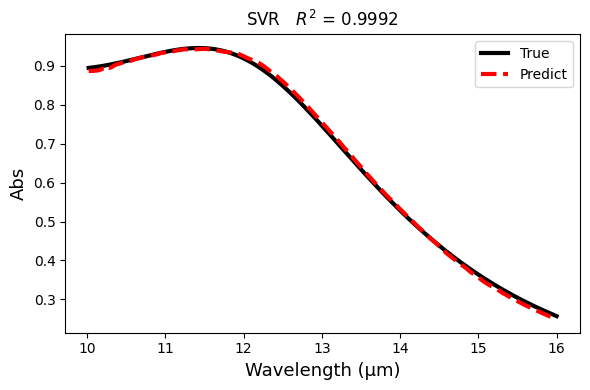

Saved: spectrum_true_vs_predict_10_16um.csv


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score


file_path = "/content/h2 = 0.2275, p = 1.43.csv"


df = pd.read_csv(file_path)

wavelength_nm = df.iloc[:, 0].to_numpy(dtype=float) * 1000
absorbance = df.iloc[:, 1].to_numpy(dtype=float)

mask_input = (wavelength_nm >= 4000) & (wavelength_nm <= 10000)

X_input = absorbance[mask_input].reshape(1, -1)

print("Input shape:", X_input.shape)

model_name = "SVR"
model = trained_models[model_name]
y_pred = model.predict(X_input)[0]

print("Predicted spectrum length:", len(y_pred))

mask_true = (wavelength_nm > 10000) & (wavelength_nm <= 16000)

y_true = absorbance[mask_true]
wavelength_true_nm = wavelength_nm[mask_true]
wavelength_true_um = wavelength_true_nm / 1000

print("True spectrum length:", len(y_true))
if len(y_true) != len(y_pred):
    raise ValueError(
        f"Length mismatch: y_true = {len(y_true)}, "
        f"y_pred = {len(y_pred)}.\n"
        "Please check the wavelength grid used during training."
    )

r2 = r2_score(y_true, y_pred)

print(f"Model : {model_name}")
print(f"R² = {r2:.4f} ({r2*100:.2f}%)वरुन")

plt.figure(figsize=(6,4))

plt.plot(
    wavelength_true_um,
    y_true,
    color="black",
    linewidth=3,
    label="True"
)

plt.plot(
    wavelength_true_um,
    y_pred,
    "--",
    color="red",
    linewidth=3,
    label="Predict"
)

plt.xlabel("Wavelength (µm)", fontsize=13)
plt.ylabel("Abs", fontsize=13)
plt.title(f"{model_name}   $R^2$ = {r2:.4f}")

plt.legend()
plt.tight_layout()
plt.show()

# ==========================================================
# Save result
# ==========================================================
df_save = pd.DataFrame({
    "Wavelength_nm": wavelength_true_nm,
    "Wavelength_um": wavelength_true_um,
    "True_Abs": y_true,
    "Predicted_Abs": y_pred
})

save_name = "spectrum_true_vs_predict_10_16um.csv"

df_save.to_csv(save_name, index=False)

print("Saved:", save_name)
